In [2]:
using Clapeyron, Metaheuristics, Printf

In [3]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
2methylpropane,58.12,2.2616,3.7574,216.53,0,0
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,2methylpropane,-0.01
"""

model = PCSAFT(["co2", "2methylpropane"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 193.60141918790265; 193.60141918790265 216.53]
[2.785e-10 3.2712e-10; 3.2712e-10 3.7574000000000004e-10]
kij = -0.010000000000000009


In [31]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 280 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 280 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [41]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 800.0,
        :guess   => 193.6
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 800.0, :param => :epsilon, :indices => (1, 2), :guess => 193.6, :lower => 10.0)

In [42]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_2methylpropane.csv")
fix_line_endings("vley_2methylpropane.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_2methylpropane.csv"
        "vley_2methylpropane.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_2methylpropane.csv
Fixed: vley_2methylpropane.csv
Initial objective value: 0.19833645027724545


In [43]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([168.43135599877553], PCSAFT{BasicIdeal, Float64}("co2", "2methylpropane"))

In [44]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 168.43135599877553; 168.43135599877553 216.53]
[2.785e-10 3.2712e-10; 3.2712e-10 3.7574000000000004e-10]
kij = 0.12130980096971777


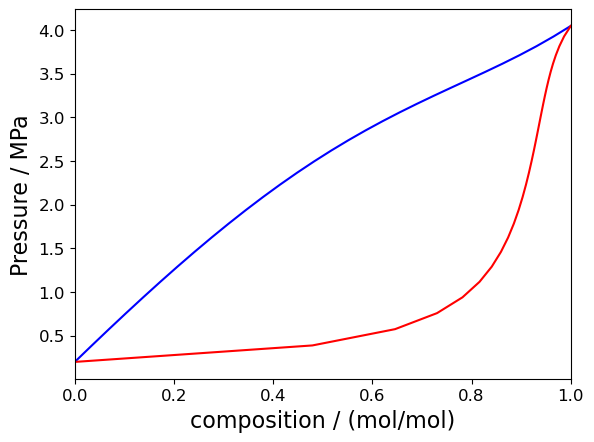

([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5], PyCall.PyObject[PyObject Text(0, 0.0, '0.0'), PyObject Text(0, 0.5, '0.5'), PyObject Text(0, 1.0, '1.0'), PyObject Text(0, 1.5, '1.5'), PyObject Text(0, 2.0, '2.0'), PyObject Text(0, 2.5, '2.5'), PyObject Text(0, 3.0, '3.0'), PyObject Text(0, 3.5, '3.5'), PyObject Text(0, 4.0, '4.0'), PyObject Text(0, 4.5, '4.5')])

In [45]:
import PyPlot; const plt = PyPlot

N    = 30
T    = 280

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [46]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [47]:
aard_p   = calculate_AAD(model_opt, "vlep_24dimethylpentane.csv", vle_p)


=== AAD: vlep_24dimethylpentane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1825      1160000.000000  1166249.138487  0.5387  
0.2980      2050000.000000  1725530.861796  15.8278 
0.4143      3070000.000000  2229863.098023  27.3660 
0.5214      4060000.000000  2633294.009756  35.1405 
0.6238      5030000.000000  2963933.337794  41.0749 
0.7224      6050000.000000  3241416.770536  46.4229 
0.7981      7050000.000000  3440702.453720  51.1957 
0.8791      8050000.000000  3659376.632225  54.5419 
0.9755      8670000.000000  3958612.354467  54.3413 
AARD = 36.2722%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


36.27218590327001

In [48]:
aard_p   = calculate_AAD(model_opt, "vley_24dimethylpentane.csv", vle_y)


=== AAD: vley_24dimethylpentane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.1825      0.973600      0.824023      15.3633 
0.2980      0.981500      0.881372      10.2015 
0.4143      0.987400      0.909792      7.8598  
0.5214      0.989400      0.926127      6.3951  
0.6238      0.990800      0.937805      5.3487  
0.7224      0.990400      0.947736      4.3078  
0.7981      0.983200      0.955812      2.7856  
0.8791      0.974100      0.966822      0.7471  
0.9755      0.975500      0.989907      1.4769  
AARD = 6.0540%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


6.053983727241925